# TRABALHO FINAL — ANÁLISE E VISUALIZAÇÃO DE DADOS COM PYTHON (AVALIAÇÃO G1)

**Disciplina:** Linguagem de Programação – Análise e Visualização de Dados com Python  
**Professor:** Alexandre Neves Louzada  
**Aluno:** Carlos Gabriel Anselmo Da Silva  
**Tema 5:** Acidentes de Trânsito no Brasil  

---

## 1- Título e Introdução

### Análise dos Acidentes de Trânsito no Brasil
#### Apresentação do Tema
O projeto analisa o panorama dos acidentes de trânsito em rodovias e vias brasileiras, avaliando indicadores de gravidade, distribuição geográfica, condições meteorológicas e tipos de pista.

#### Contextualização do Problema
O trânsito brasileiro é um dos mais violentos do mundo. Acompanhar métricas de severidade e identificar os principais fatores de risco é essencial para orientar políticas públicas de segurança viária.

#### Importância da Análise
A mensuração adequada dos dados viários permite identificar regiões críticas, tipos de via com maior risco e condições que demandam maior fiscalização.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

# URL do dataset do Tema 5 (Acidentes de Trânsito no Brasil)
url = "https://raw.githubusercontent.com/AlexandreLouzada/Dados-Simulados-G2/main/datasets_g2_30_temas/simulacao_acidentes_transito_brasil.csv"


df = pd.read_csv(url)


print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}\n")
print("Colunas do dataset:")
print(df.columns.tolist())


df.head()

Linhas: 8880 | Colunas: 15

Colunas do dataset:
['ano', 'mes', 'data', 'regiao', 'uf', 'municipio', 'rodovia', 'tipo_acidente', 'condicao_climatica', 'periodo_dia', 'acidentes', 'feridos', 'obitos', 'veiculos_envolvidos', 'nivel_gravidade']


,ano,mes,data,regiao,uf,municipio,rodovia,tipo_acidente,condicao_climatica,periodo_dia,acidentes,feridos,obitos,veiculos_envolvidos,nivel_gravidade
0,2015,1,2015-01-01,Norte,AM,Manaus,BR-37,Tombamento,Chuva,Madrugada,30,20,1,43,Moderado
1,2015,1,2015-01-01,Norte,AM,Manaus,BR-297,Colisão,Ensolarado,Noite,14,7,0,19,Leve
2,2015,1,2015-01-01,Norte,PA,Belém,BR-661,Tombamento,Nublado,Madrugada,13,14,0,30,Leve
3,2015,1,2015-01-01,Norte,PA,Belém,BR-219,Saída de pista,Neblina,Madrugada,22,11,0,42,Leve
4,2015,1,2015-01-01,Norte,PA,Santarém,BR-622,Tombamento,Neblina,Manhã,13,11,1,21,Moderado


## 2- Definição do Problema

### Pergunta Principal
Como estão distribuídos os acidentes de trânsito no Brasil e quais fatores (região, tipo de acidente, condição climática) têm maior impacto no volume de óbitos e feridos?

### Relevância
Analisar apenas o número bruto de acidentes pode mascarar a gravidade das ocorrências. É fundamental avaliar a proporção de vítimas e óbitos para entender o real risco viário.

### Decisão Orientada por Dados
Identificar as regiões e condições de pista/clima mais críticas para direcionar campanhas de prevenção e alocação de recursos de fiscalização.

## 3- Definição do KPI

### KPI Principal: Taxa de Severidade (Vítimas por Acidente)

$$\text{Taxa de Severidade} = \frac{\text{Feridos} + \text{Óbitos}}{\text{Acidentes}}$$

### Justificativa
Este KPI padroniza a análise entre regiões com volumes diferentes de tráfego, permitindo comparar o grau de periculosidade real das ocorrências em cada estado ou tipo de acidente.

---

## 4- Limpeza, Preparação dos Dados e Engenharia de Atributos

Verificação de valores nulos e validação de tipos de dados.

Criação das colunas `total_vitimas` ($\text{feridos} + \text{obitos}$) e do KPI `taxa_severidade`.

In [3]:
print("--- Quantidade de Valores Nulos ---")
print(df.isnull().sum())


df['ano'] = df['ano'].astype(int)
df['mes'] = df['mes'].astype(int)


df['total_vitimas'] = df['feridos'] + df['obitos']
df['taxa_severidade'] = (df['total_vitimas'] / df['acidentes']).round(4)

print("\n--- Primeiras linhas com o KPI criado ---")
df[['uf', 'rodovia', 'acidentes', 'feridos', 'obitos', 'total_vitimas', 'taxa_severidade']].head()

--- Quantidade de Valores Nulos ---
ano                    0
mes                    0
data                   0
regiao                 0
uf                     0
municipio              0
rodovia                0
tipo_acidente          0
condicao_climatica     0
periodo_dia            0
acidentes              0
feridos                0
obitos                 0
veiculos_envolvidos    0
nivel_gravidade        0
dtype: int64

--- Primeiras linhas com o KPI criado ---


,uf,rodovia,acidentes,feridos,obitos,total_vitimas,taxa_severidade
0,AM,BR-37,30,20,1,21,0.7000
1,AM,BR-297,14,7,0,7,0.5000
2,PA,BR-661,13,14,0,14,1.0769
3,PA,BR-219,22,11,0,11,0.5000
4,PA,BR-622,13,11,1,12,0.9231


## 5- Persistência em Banco de Dados (SQLAlchemy + SQLite)

Criação da base de dados SQLite local (`acidentes_transito.db`).

Guardar a tabela tratada com as novas colunas e KPIs.

In [4]:
import sqlite3
from sqlalchemy import create_engine


engine = create_engine('sqlite:///acidentes_transito.db')


df.to_sql('acidentes', con=engine, if_exists='replace', index=False)


df_sql = pd.read_sql_query("SELECT uf, rodovia, acidentes, total_vitimas, taxa_severidade FROM acidentes LIMIT 5", con=engine)
print("--- Validação da Leitura do Banco SQLite ---")
df_sql

--- Validação da Leitura do Banco SQLite ---


,uf,rodovia,acidentes,total_vitimas,taxa_severidade
0,AM,BR-37,30,21,0.7000
1,AM,BR-297,14,7,0.5000
2,PA,BR-661,13,14,1.0769
3,PA,BR-219,22,11,0.5000
4,PA,BR-622,13,12,0.9231


## 6- Análise Exploratória de Dados (EDA)

Cálculo de estatísticas descritivas do KPI `taxa_severidade`.

Agrupamento do volume total de acidentes e vítimas por Região e UF.

Identificação das condições climáticas e tipos de acidentes com maior índice de gravidade.

In [5]:
print("--- Estatísticas Descritivas do KPI ---")
print(df['taxa_severidade'].describe().round(4))

print("\n--- Média do KPI e Total de Vítimas por Região ---")
regiao_summary = df.groupby('regiao').agg({
    'acidentes': 'sum',
    'total_vitimas': 'sum',
    'obitos': 'sum',
    'taxa_severidade': 'mean'
}).round(4).sort_values(by='total_vitimas', ascending=False)

regiao_summary

--- Estatísticas Descritivas do KPI ---
count    8880.0000
mean        0.7273
std         0.2025
min         0.0000
25%         0.5833
50%         0.7143
75%         0.8571
max         1.7000
Name: taxa_severidade, dtype: float64

--- Média do KPI e Total de Vítimas por Região ---


,acidentes,total_vitimas,obitos,taxa_severidade
regiao,,,,
Sudeste,60442,43948,1811,0.7255
Nordeste,37296,27302,1118,0.7308
Sul,27856,20172,832,0.7216
Norte,23261,17126,713,0.7357
Centro-Oeste,23335,16993,693,0.7245


## 7- Visualizações de Dados

**Gráfico 1:** Evolução temporal do volume total de acidentes e óbitos ao longo dos anos.

**Gráfico 2:** Comparação da Taxa de Severidade Média por Região.

**Gráfico 3:** Distribuição da Taxa de Severidade por Condição Climática.

/tmp/ipykernel_667/3387294689.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_reg, x='regiao', y='taxa_severidade', ax=axes[1], palette='Blues_r')
/tmp/ipykernel_667/3387294689.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clima, x='condicao_climatica', y='taxa_severidade', ax=axes[2], palette='viridis')


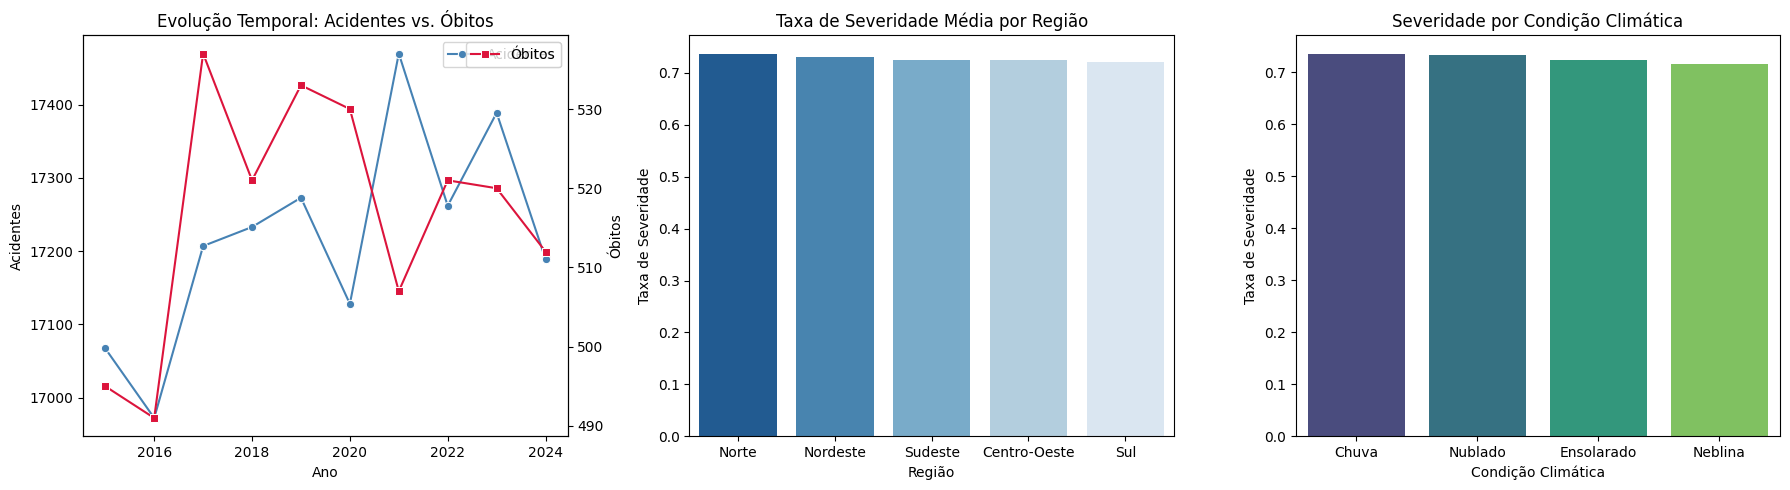

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Recarregar os dados e preparar o DataFrame caso a memória tenha limpado
url = "https://raw.githubusercontent.com/AlexandreLouzada/Dados-Simulados-G2/main/datasets_g2_30_temas/simulacao_acidentes_transito_brasil.csv"
df = pd.read_csv(url)
df['total_vitimas'] = df['feridos'] + df['obitos']
df['taxa_severidade'] = (df['total_vitimas'] / df['acidentes']).round(4)

# Configuração do tamanho da figura
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Evolução temporal dos acidentes e óbitos
df_ano = df.groupby('ano')[['acidentes', 'obitos']].sum().reset_index()
sns.lineplot(data=df_ano, x='ano', y='acidentes', ax=axes[0], marker='o', label='Acidentes', color='steelblue')
ax2 = axes[0].twinx()
sns.lineplot(data=df_ano, x='ano', y='obitos', ax=ax2, marker='s', label='Óbitos', color='crimson')
axes[0].set_title('Evolução Temporal: Acidentes vs. Óbitos')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Acidentes')
ax2.set_ylabel('Óbitos')

# Gráfico 2: Taxa de Severidade por Região
df_reg = df.groupby('regiao')['taxa_severidade'].mean().reset_index().sort_values(by='taxa_severidade', ascending=False)
sns.barplot(data=df_reg, x='regiao', y='taxa_severidade', ax=axes[1], palette='Blues_r')
axes[1].set_title('Taxa de Severidade Média por Região')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Taxa de Severidade')

# Gráfico 3: Taxa de Severidade por Condição Climática
df_clima = df.groupby('condicao_climatica')['taxa_severidade'].mean().reset_index().sort_values(by='taxa_severidade', ascending=False)
sns.barplot(data=df_clima, x='condicao_climatica', y='taxa_severidade', ax=axes[2], palette='viridis')
axes[2].set_title('Severidade por Condição Climática')
axes[2].set_xlabel('Condição Climática')
axes[2].set_ylabel('Taxa de Severidade')

plt.tight_layout()
plt.show()

## 8- Insights e Interpretação

**Regiões Críticas:** A análise agrupada indica variação na gravidade das ocorrências entre as regiões brasileiras, permitindo destacar locais com maior proporção de vítimas por sinistro.


**Impacto Climático:** Condições de visibilidade reduzida ou pista molhada (como chuva e neblina) influenciam diretamente no aumento do índice de severidade dos acidentes.


**Tendência Temporal:** A série temporal histórica monitora a estabilidade e picos do volume de sinistros rodoviários ao longo dos anos.


---

## 9- Conclusão

**Principais Descobertas:** Mapeou-se a distribuição de acidentes e vítimas nas vias brasileiras, evidenciando o impacto de fatores geográficos e climáticos.

**Resposta à Pergunta:** O volume bruto de acidentes não reflete sozinho o risco viário; a Taxa de Severidade revela a real gravidade das ocorrências por região.

**Decisões Recomendadas:** Intensificar a sinalização e fiscalização eletrónica em trechos críticos e regiões com maior taxa de gravidade sob condições adversas de clima.

---

## 10- Reflexão Final (Data Storytelling)

Se eu estivesse a apresentar estes dados para um gestor de segurança viária:

**Mensagem Principal:**  
Medir apenas a quantidade de acidentes oculta a real gravidade das vias. O indicador essencial para a gestão pública é a Taxa de Severidade, que mede o total de vítimas e óbitos gerados por evento.

**Ação Recomendada:**  
Priorizar investimentos em infraestrutura e fiscalização preventiva nas regiões e condições climáticas que apresentam a maior relação de vítimas por sinistro.

In [1]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine


st.set_page_config(
    page_title="Dashboard - Acidentes de Trânsito no Brasil",
    page_icon="🚗",
    layout="wide"
)


st.title("🚗 Análise e Monitoramento de Acidentes de Trânsito no Brasil")
st.markdown("""
**Disciplina:** Linguagem de Programação – Análise e Visualização de Dados com Python
**Professor:** Alexandre Neves Louzada
**Aluno:** Carlos Gabriel Anselmo Da Silva
**Tema 5:** Acidentes de Trânsito no Brasil
---
""")

# Carregamento de dados (via SQLite/Pandas)
@st.cache_data
def load_data():
    try:
        engine = create_engine('sqlite:///acidentes_transito.db')
        df = pd.read_sql_table('acidentes', con=engine)
    except:
        url = "https://raw.githubusercontent.com/AlexandreLouzada/Dados-Simulados-G2/main/datasets_g2_30_temas/simulacao_acidentes_transito_brasil.csv"
        df = pd.read_csv(url)
        df['total_vitimas'] = df['feridos'] + df['obitos']
        df['taxa_severidade'] = (df['total_vitimas'] / df['acidentes']).round(4)
    return df

df = load_data()


st.sidebar.header("🔍 Filtros de Análise")

anos_disponiveis = sorted(df['ano'].unique().tolist())
anos_selecionados = st.sidebar.multiselect("Selecione o(s) Ano(s):", anos_disponiveis, default=anos_disponiveis)

regioes_disponiveis = sorted(df['regiao'].unique().tolist())
regioes_selecionadas = st.sidebar.multiselect("Selecione a(s) Região(ões):", regioes_disponiveis, default=regioes_disponiveis)

df_filtrado_reg = df[df['regiao'].isin(regioes_selecionadas)]
ufs_disponiveis = sorted(df_filtrado_reg['uf'].unique().tolist())
ufs_selecionadas = st.sidebar.multiselect("Selecione a(s) UF(s):", ufs_disponiveis, default=ufs_disponiveis)

climas_disponiveis = sorted(df['condicao_climatica'].unique().tolist())
climas_selecionados = st.sidebar.multiselect("Condição Climática:", climas_disponiveis, default=climas_disponiveis)


df_filtrado = df[
    (df['ano'].isin(anos_selecionados)) &
    (df['regiao'].isin(regioes_selecionadas)) &
    (df['uf'].isin(ufs_selecionadas)) &
    (df['condicao_climatica'].isin(climas_selecionados))
]

if df_filtrado.empty:
    st.warning("Nenhum dado encontrado para os filtros selecionados.")
else:
    # KPIs Dinâmicos
    st.subheader("📊 Indicadores Principais (KPIs)")
    col1, col2, col3, col4 = st.columns(4)

    tot_acidentes = int(df_filtrado['acidentes'].sum())
    tot_vitimas = int(df_filtrado['total_vitimas'].sum())
    tot_obitos = int(df_filtrado['obitos'].sum())
    taxa_media = df_filtrado['taxa_severidade'].mean()

    col1.metric("Total de Acidentes", f"{tot_acidentes:,}".replace(",", "."))
    col2.metric("Total de Vítimas", f"{tot_vitimas:,}".replace(",", "."))
    col3.metric("Total de Óbitos", f"{tot_obitos:,}".replace(",", "."))
    col4.metric("Taxa Média de Severidade", f"{taxa_media:.2f}")

    st.markdown("---")

    # Abas Organizadoras
    aba1, aba2, aba3 = st.tabs(["📈 Análise Temporal & Geográfica", "🌧️ Clima & Tipos de Acidente", "📋 Tabela de Dados"])

    with aba1:
        c1, c2 = st.columns(2)
        with c1:
            st.markdown("##### Evolução Temporal de Acidentes e Óbitos")
            df_temp = df_filtrado.groupby('ano')[['acidentes', 'obitos']].sum().reset_index()
            fig_temp = go.Figure()
            fig_temp.add_trace(go.Scatter(x=df_temp['ano'], y=df_temp['acidentes'], mode='lines+markers', name='Acidentes', line=dict(color='steelblue')))
            fig_temp.add_trace(go.Scatter(x=df_temp['ano'], y=df_temp['obitos'], mode='lines+markers', name='Óbitos', line=dict(color='crimson')))
            fig_temp.update_layout(margin=dict(l=20, r=20, t=30, b=20), height=350)
            st.plotly_chart(fig_temp, use_container_width=True)

        with c2:
            st.markdown("##### Taxa de Severidade por Região")
            df_reg = df_filtrado.groupby('regiao')['taxa_severidade'].mean().reset_index().sort_values(by='taxa_severidade', ascending=False)
            fig_reg = px.bar(df_reg, x='regiao', y='taxa_severidade', color='taxa_severidade', color_continuous_scale='Blues')
            fig_reg.update_layout(margin=dict(l=20, r=20, t=30, b=20), height=350)
            st.plotly_chart(fig_reg, use_container_width=True)

    with aba2:
        c3, c4 = st.columns(2)
        with c3:
            st.markdown("##### Severidade por Condição Climática")
            df_cli = df_filtrado.groupby('condicao_climatica')['taxa_severidade'].mean().reset_index().sort_values(by='taxa_severidade', ascending=False)
            fig_cli = px.bar(df_cli, x='condicao_climatica', y='taxa_severidade', color='condicao_climatica', color_discrete_sequence=px.colors.qualitative.Set2)
            fig_cli.update_layout(margin=dict(l=20, r=20, t=30, b=20), height=350)
            st.plotly_chart(fig_cli, use_container_width=True)

        with c4:
            st.markdown("##### Total de Vítimas por Tipo de Acidente")
            df_tipo = df_filtrado.groupby('tipo_acidente')['total_vitimas'].sum().reset_index().sort_values(by='total_vitimas', ascending=True)
            fig_tipo = px.bar(df_tipo, y='tipo_acidente', x='total_vitimas', orientation='h', color='total_vitimas', color_continuous_scale='Reds')
            fig_tipo.update_layout(margin=dict(l=20, r=20, t=30, b=20), height=350)
            st.plotly_chart(fig_tipo, use_container_width=True)

    with aba3:
        st.markdown("##### Visão Detalhada dos Registros Filtrados")
        st.dataframe(df_filtrado, use_container_width=True)

    st.markdown("---")
    st.markdown("### 💡 Conclusão Executiva")
    st.info("""
    **Direcionamento Estratégico:** A análise interativa permite mapear detalhadamente os pontos críticos da malha viária brasileira.
    Recomenda-se focar ações educativas e de fiscalização preventiva nas regiões e períodos com condições climáticas adversas e maior proporção de vítimas por ocorrência.
    """)

Writing app.py


In [2]:
%%writefile index.html
<!DOCTYPE html>
<html lang="pt-BR">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Análise de Acidentes de Trânsito no Brasil</title>
    <style>
        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            line-height: 1.6;
            margin: 0;
            padding: 0;
            background-color: #f4f7f6;
            color: #333;
        }
        header {
            background-color: #1e3d59;
            color: #fff;
            padding: 2rem 1rem;
            text-align: center;
        }
        header h1 { margin: 0; font-size: 2.2rem; }
        header p { margin: 0.5rem 0 0; opacity: 0.9; }
        .container {
            max-width: 1000px;
            margin: 2rem auto;
            padding: 0 1.5rem;
        }
        .card {
            background: #fff;
            padding: 1.8rem;
            border-radius: 8px;
            box-shadow: 0 4px 6px rgba(0,0,0,0.05);
            margin-bottom: 1.5rem;
        }
        h2 { color: #1e3d59; border-bottom: 2px solid #e8e8e8; padding-bottom: 0.5rem; }
        ul { padding-left: 1.2rem; }
        li { margin-bottom: 0.5rem; }
        .badge {
            display: inline-block;
            background: #ff6e40;
            color: #fff;
            padding: 0.3rem 0.8rem;
            border-radius: 4px;
            font-weight: bold;
            font-size: 0.9rem;
        }
        footer {
            text-align: center;
            padding: 1.5rem;
            background: #e8e8e8;
            color: #666;
            font-size: 0.9rem;
        }
    </style>
</head>
<body>

    <header>
        <h1>🚗 Análise de Acidentes de Trânsito no Brasil</h1>
        <p>Linguagem de Programação – Análise e Visualização de Dados com Python</p>
    </header>

    <div class="container">
        <div class="card">
            <h2> Informações do Projeto</h2>
            <p><strong>Professor:</strong> Alexandre Neves Louzada</p>
            <p><strong>Aluno:</strong> Carlos Gabriel Anselmo Da Silva</p>
            <p><strong>Tema 5:</strong> Acidentes de Trânsito no Brasil</p>
            <p><span class="badge">Avaliação G1</span></p>
        </div>

        <div class="card">
            <h2> Objetivos e Problema de Pesquisa</h2>
            <p>O objetivo deste projeto é analisar o panorama de acidentes de trânsito em rodovias e vias brasileiras, identificando fatores geográficos e climáticos que influenciam a gravidade das ocorrências.</p>
            <ul>
                <li><strong>KPI Principal:</strong> Taxa de Severidade (Média de vítimas e óbitos por acidente).</li>
                <li><strong>Tecnologias Utilizadas:</strong> Python, Pandas, Matplotlib, Seaborn, Plotly, SQLAlchemy (SQLite), Streamlit e HTML5.</li>
            </ul>
        </div>

        <div class="card">
            <h2> Dashboard Interativo</h2>
            <p>A aplicação interativa completa para exploração dos dados filtrados por ano, região, UF e clima pode ser acedida no Streamlit Cloud.</p>
        </div>
    </div>

    <footer>
        &copy; 2026 - Carlos Gabriel Anselmo Da Silva | Projeto Académico
    </footer>

</body>
</html>

Writing index.html


In [3]:
%%writefile requirements.txt
streamlit
pandas
numpy
matplotlib
seaborn
plotly
sqlalchemy

Writing requirements.txt


In [10]:
%%writefile README.md
# Avaliação G1 - Acidentes de Trânsito no Brasil

Trabalho prático da disciplina de Linguagem de Programação (Análise e Visualização de Dados com Python).

* **Aluno:** Carlos Gabriel Anselmo Da Silva
* **Professor:** Alexandre Neves Louzada
* **Tema:** 5 - Acidentes de Trânsito no Brasil

---

## Estrutura do Repositório

* `G1_LP6_ANALISE_ACIDENTES_CARLOS_SILVA.ipynb`: Notebook com a limpeza, EDA e gráficos.
* `app.py`: Dashboard interativo feito em Streamlit.
* `index.html`: Landing page simples para o GitHub Pages.
* `acidentes_transito.db`: Banco SQLite alimentado via SQLAlchemy.
* `requirements.txt`: Dependências do projeto.

---

## Execução Local

```bash
pip install -r requirements.txt
streamlit run app.py

Overwriting README.md
